# Exercise - ANN Multi Input/Output and Hypertuning for SAR Prediction in VHP Head Model (3)

Exercise in the lecture Machine Learning in Electrical Engineering and Information Technology, Prediction of the Specific Absorption Rate (SAR)

* Lecture Period: Summer 2026 ([StudIP](https://e-learning.tuhh.de/studip/dispatch.php/course/details/index/1be148fc0ce85172e3902adf814a909b))
* Institute: Institut für Theoretische Elektrotechnik ([TET](https://www.tet.tuhh.de/en/))
* University: Hamburg University of Technology ([TUHH](https://www.tuhh.de/tuhh/en/startpage))
* Exercise Supervisor: Malte Thode


The third part of the exercise is about the prediction of the Specific Absorption Rate (SAR) inside a human head model. The human head model consists of multiple tissues that vary in their electric properties. The difference from exercise two is that here the prediction is to be carried out for multiple tissues simultaneously and ANN parameters are tunned for some comparison with previous results before hypertuning.

|||
|:-:|:-:|
|<img title="head exposed to fields" src='figures/model8_2.PNG' width='500'/>|<img title="tissues of the human head model" src='figures/SAR_VHP.png' width='500'/>|
|**VHP Head Model**|**SAR Distribution using FEM Solver**|

### This notebook is structured as follows:
* Loading of required python modules, including a helper module
* Loading the data from the specified CSV file
* Choosing input and output features
* Scaling the data
* Training neural networks
* Evaluating neural networks 

### How to work with the notebook

Each section consists of 2 to 3 cells. The first cell is an introduction to the section and explains the behavior of the following cells. Settings or variables are set in the following cell. Make your settings as you want and run the cell. The cell after is a *code cell*. You do not need to make any settings here, just run the code.

|-|
|:-:|
|<img title="How to Work with the Notebook!" src='figures/cell_setup_2.png' width='700'/>|
|**How to work with the Notebook!**|

#### Module Import
**Modules** are imported, which have to be available to the python interpreter.  
**helper_functions (hp)** is a module in the working directory providing some functions making the notebook more tidy.

**Module Links for Further Information:**
* [pandas](https://pandas.pydata.org/)
* [numpy](https://numpy.org/)
* [matplotlib](https://matplotlib.org/)
* [pickle](https://docs.python.org/3/library/pickle.html)
* [scikit-learn](https://scikit-learn.org/stable/index.html)

In [1]:
# code cell
from sklearn.neural_network import MLPRegressor
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import os as os
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as sm
import numpy as np
from sklearn.model_selection import GridSearchCV


#import helper.helper_functions as hp # toolbox providing functionality -> resulting in cleaner looking notebook

#### Load Data from Working Directory

From the local directory the CSV file is loaded. The electromagntic properties of the different tissues are varied and given in the table. The ***conductivity*** and ***relative permitivitty*** of each tissue represent the ***input features***. The resulting ***SAR*** in the different tissues after simulation represent the ***output*** features.

All data samples are split in **Test** and **Train** data before any operations (scaling, ...) are performed.  

**Variables:**
* *test_size* &rarr; share of data used for testing the trained neural network
* *file_name* &rarr; file containing the data

In [2]:
# variables
test_size = 0.2
file_name = "data/task_3.csv"

In [3]:
data_set = pd.read_csv(file_name)
sar_cols = [c for c in data_set.columns if c.startswith('SAR_')]
for col in sar_cols:
    data_set[col] = data_set[col] * 1000
    data_set.rename(columns={col: col.replace('(W/kG)', '(mW/kg)')}, inplace=True)
pd.set_option('display.max_columns', None)
display(data_set.head())

,Eps_blood,Eps_bodyAverage,Eps_boneCortical,Eps_brainGreyMatter,Eps_brainWhiteMatter,Eps_cartilage,Eps_cerebellum,Eps_cerebrospinalFluid,Eps_eyeVitrousHumor,Eps_fatAverageInfiltrated,Eps_nerve,Eps_skin,Eps_tongue,Eps_tooth,Cond_blood(S/m),Cond_bodyAverage(S/m),Cond_boneCortical(S/m),Cond_brainGreyMatter(S/m),Cond_brainWhiteMatter(S/m),Cond_cartilage(S/m),Cond_cerebellum(S/m),Cond_cerebrospinalFluid(S/m),Cond_eyeVitrousHumor(S/m),Cond_fatAverageInfiltrated(S/m),Cond_nerve(S/m),Cond_skin(S/m),Cond_tongue(S/m),Cond_tooth(S/m),SAR_blood(mW/kg),SAR_bodyAverage(mW/kg),SAR_boneCortical(mW/kg),SAR_brainGreyMatter(mW/kg),SAR_brainWhiteMatter(mW/kg),SAR_cartilage(mW/kg),SAR_cerebellum(mW/kg),SAR_cerebrospinalFluid(mW/kg),SAR_eyeVitrousHumor(mW/kg),SAR_fatAverageInfiltrated(mW/kg),SAR_nerve(mW/kg),SAR_skin(mW/kg),SAR_tongue(mW/kg),SAR_tooth(mW/kg),SAR_max(mW/kg)
0,213.304441,137.340829,27.261918,248.374777,171.316061,128.622449,349.622381,92.623836,72.774791,27.869940,121.905593,327.059156,173.424657,31.422336,1.026077,0.627977,0.039758,0.281984,0.189893,0.401758,0.491994,2.072056,1.513320,0.052011,0.228942,0.262527,0.652324,0.041293,0.751290,0.353854,0.194615,0.195965,0.149979,2.211873,0.383948,1.848676,0.056971,0.445523,0.228985,0.401252,0.140200,0.007425,2.211873
1,230.581074,120.815896,34.940186,225.366658,149.852035,130.371693,355.144636,114.894013,63.531107,24.301469,127.157757,304.409876,180.859730,31.401085,0.990097,0.542837,0.043061,0.301486,0.159592,0.405785,0.446913,2.141811,1.690317,0.055034,0.258752,0.271986,0.592679,0.044412,0.774816,0.344230,0.181085,0.203413,0.135612,2.563053,0.368789,1.866396,0.044721,0.435152,0.262924,0.398236,0.146815,0.008826,2.563053
2,227.977126,126.028505,32.462032,228.303351,168.611134,139.595331,383.033851,105.327273,78.034323,28.728686,129.456714,263.174573,144.174667,28.614143,1.064887,0.688818,0.041371,0.301067,0.154175,0.400450,0.437590,1.945106,1.599282,0.054454,0.266583,0.243809,0.505471,0.051320,0.736982,0.361148,0.182813,0.213566,0.137347,2.018507,0.365310,1.803814,0.061681,0.423569,0.247159,0.362082,0.122340,0.009092,2.018507
3,187.693142,130.005210,27.309981,246.363504,166.130195,146.474017,381.715258,103.740564,78.283802,28.668307,132.445628,313.509316,141.242928,30.285059,1.249235,0.677501,0.044420,0.311940,0.162479,0.334472,0.440733,1.997302,1.356690,0.057816,0.268330,0.259650,0.597291,0.039526,0.778670,0.357296,0.190298,0.211463,0.138640,1.766862,0.368797,1.791076,0.063240,0.406059,0.248650,0.358893,0.132200,0.007283,1.791076
4,193.239816,125.495530,30.265481,252.820374,173.361470,150.386422,353.345159,93.888970,72.768746,22.408424,127.698439,291.681333,176.779322,34.009850,1.099634,0.655387,0.038846,0.375926,0.164448,0.369080,0.442055,2.167626,1.550480,0.050380,0.218862,0.266649,0.643891,0.039692,0.766565,0.357435,0.191762,0.221022,0.127126,2.030288,0.383557,1.765305,0.065918,0.452848,0.221088,0.378847,0.140199,0.007667,2.030288


#### Choosing input and output features

From the loaded file, the input and output features have to be chosen. For this specific task, all the electromagntic properties of the different tissues are to be selected as input. The SAR values of multiple tissues are chosen as the output. The selection of the input features is carried out using indices because of the large number of features. The 10 first tissues are chosen as output parameters

In [4]:
# code cell
data_set_train, data_set_test = train_test_split(data_set, test_size=test_size, shuffle=True)

# separate input and output data
train_input = data_set_train.iloc[:, 0:28]
train_output = data_set_train.iloc[:, 28:38]
test_input = data_set_test.iloc[:, 0:28]
test_output = data_set_test.iloc[:, 28:38]

#### Scaling of Data
A scaler is used to scale the input features. The scaler is fitted on the train data only, and applied to the train and test data. Feature scaling usually makes the training faster. It prevents the optimization from getting stuck in local optima.

In [5]:
scaler = StandardScaler()
scaler.fit(train_input)

train_input_scaled = scaler.transform(train_input)
test_input_scaled = scaler.transform(test_input)

#### Training Neural Networks

**Sklearn** provides methods to train different kind of machine learning tools e.g. neural networks. To predict the SAR values inside the sphere, we have to define a regressor. The topology and training parameters of the neural network are defined and set before train.

**Variables:**
* *hidden_layer_sizes* &rarr; topologies of neural networks
* *solver* &rarr; solver used during training the neural network and optimizing the weights
* *learning_rate_init* &rarr; initial learning rates used for the solver
* *learning_rate* &rarr; type of learning rate
* *max_iter* &rarr; maximum number of iterations before termination of the training 
* *activation* &rarr; activation function for the hidden layer.
* *alpha* &rarr; strength of the L2 regularization term. 
* *n_iter_no_change* &rarr; maximum number of epochs to not meet tol improvement.
* *early_stopping* &rarr; Whether to use early stopping to terminate training when validation score is not improving

Possible parameters can be identified on https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html


In [6]:
# variables
param_grid = {'hidden_layer_sizes' : (5,),
              'learning_rate_init' : 1e-2,
              'learning_rate' : 'adaptive',
              'solver' : 'adam',
              'max_iter' : 20000,
              'activation' : 'tanh',
              'alpha' : 0.0001,
              'n_iter_no_change' : 50, 
              'tol': 1e-5,
              'early_stopping' : True,
              }

In [7]:
# A regressor is chosen and set according to the previously defined variables
NN = MLPRegressor(**param_grid)

# The model is trained on the training set
NN.fit(train_input_scaled, train_output)

MLPRegressor(activation='tanh', early_stopping=True, hidden_layer_sizes=(5,),
             learning_rate='adaptive', learning_rate_init=0.01, max_iter=20000,
             n_iter_no_change=50, tol=1e-05)

#### Evaluating Neural Network Training

After training the neural networks, the networks are evaluated. There are many different metrics to evaluate the performance of the neural network including scores and errors (mean squared error, mean absolute error, ...). Plots of the loss curve and prediction of the test samples give a better insight on the performance.

* *Training and testing scores* &rarr; coefficient of determination R² that measures how well a statistical model predicts an outcome.
* *Mean absolute error* &rarr; average of the absolute errors between predictions and actual values.
* *Mean squared error* &rarr; average of the squares of the errors between predictions and actual values.
* *Median absolute error* &rarr; median of the absolute errors between predictions and actual values.
* *explained variance score* &rarr; measure of the dispersion of errors.
* *most widely used correlation* &rarr; coefficient to measure a linear correlation.

More informations on metrics and scoring on https://scikit-learn.org/stable/modules/model_evaluation.html#model-evaluation

#### Output Prediction and Scores Calculation
Predict the outputs and calculate the error and scores for the prediction

In [8]:
# Predicting unseen test input data by the trained model

In [9]:
# Scores & Errors

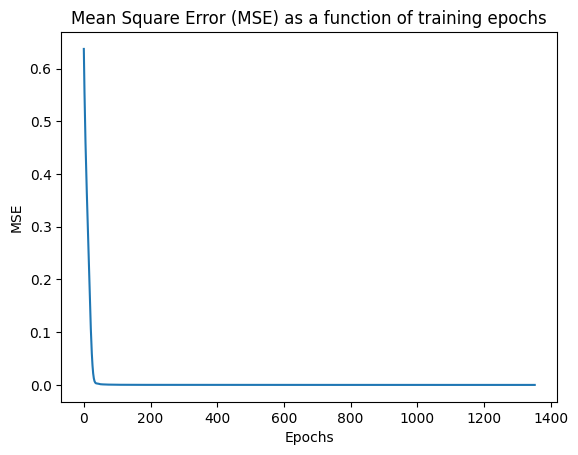

In [10]:
# plot of the evolution of the MSE 
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
plt.plot(NN.loss_curve_)
#plt.legend("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Mean Square Error (MSE) as a function of training epochs")
plt.show()

NameError: name 'NN_pred' is not defined

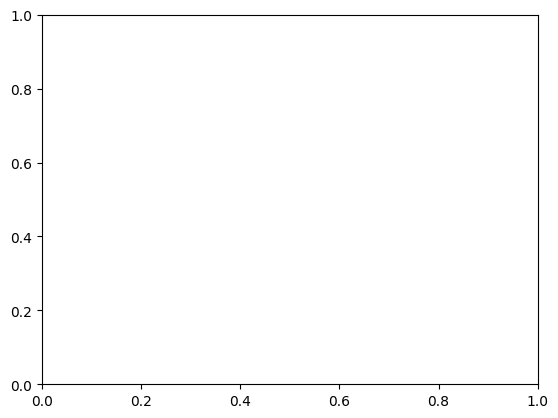

In [11]:
# plot of the actual and predicted SAR, the perfect prediction line is also highlighted for comparison
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
fig, ax = plt.subplots()
ax.scatter(test_output, NN_pred, edgecolors=(0, 0, 0), label='Test Points')
ax.set_xlabel("SAR from simulation (mW/Kg)")
ax.set_ylabel("Predicted SAR (mW/Kg)")
# Fixed: renamed min/max variables to avoid shadowing Python built-ins
ax_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
ax_max = max(ax.get_xlim()[-1], ax.get_ylim()[-1])
ax.plot([ax_min, ax_max], [ax_min, ax_max], label='Perfect Prediction', c='r', lw=3, alpha=0.6)
plt.title("Actual and predicted SAR values of the test points")
ax.legend()
plt.show()


#### Hyperparameter Tuning

Since we increased the number of chosen tissues as outputs the problem has gotten more complex. We might need to increase the complexity and change the topology of the ANNs. In order to find the best topology, we carry a hyperparameter tuning. [scikit-learn](https://scikit-learn.org/stable/index.html) provides an exhaustive search over specified parameter values for an estimator called GridSearchCV. 
GridSearchCV takes a dictionary of variables and the variations to be explored as input. 

**parameters:**
* *cv* &rarr; number of runs for the cross validation of each parameter combination.
* *verbose* &rarr; controls the verbosity: the higher, the more messages

More informations can be found on: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html



In [ ]:
# variables
param_grid = {'learning_rate_init' : 1e-2,
              'learning_rate' : 'adaptive',
              'solver' : 'adam',
              'max_iter' : 20000,
              'activation' : 'tanh',
              'alpha' : 0.0001,
              'n_iter_no_change' : 50, 
              'tol': 1e-5,
              'early_stopping' : True,
              }

tuning_grid = {
    'hidden_layer_sizes': [(5,), (10,), (15,), (5,5,), (10,10,), (15,15,), (5,5,5,), (10,10,10,), (15,15,15,)]
}

In [ ]:
#grid search
gs = GridSearchCV(NN, tuning_grid,  cv=10, verbose=2)
gs = gs.fit(train_input_scaled, train_output)

#### Retraining The Best Neural Network Training

After the grid search, the best topology and model can be identified. The best model is then retrained for evaluation. 

In [ ]:
# showing the parameters of the best model
NN_best = gs.best_estimator_
print("best model:", NN_best.get_params())

In [ ]:
# training the best model
NN_best.fit(train_input_scaled, train_output)

In [ ]:
# Predicting unseen test input data by the trained model
NN_pred = NN_best.predict(test_input_scaled)

In [ ]:
# Scores & Errors for the best model after hyperparameter tuning
print('training score : ', NN_best.score(train_input_scaled, train_output))
print('testing score  : ', NN_best.score(test_input_scaled, test_output))

print("Mean absolute error =", sm.mean_absolute_error(test_output, NN_pred))
print("Mean squared error =", sm.mean_squared_error(test_output, NN_pred))
print("Median absolute error =", sm.median_absolute_error(test_output, NN_pred))
print("Explained variance score =", sm.explained_variance_score(test_output, NN_pred))
print("R2 score =", sm.r2_score(test_output, NN_pred))
corr_values = [pearsonr(NN_pred[:, i], test_output.values[:, i])[0] for i in range(NN_pred.shape[1])]
print('Mean Pearsons correlation across outputs: %.3f' % (sum(corr_values) / len(corr_values)))

# Loss curve for the best retrained model
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
plt.plot(NN_best.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("MSE as a function of training epochs (best model)")
plt.show()

# Predicted vs actual scatter for the best model
fig, ax = plt.subplots()
ax.scatter(test_output, NN_pred, edgecolors=(0, 0, 0), label='Test Points')
ax.set_xlabel("SAR from simulation (mW/Kg)")
ax.set_ylabel("Predicted SAR (mW/Kg)")
ax_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
ax_max = max(ax.get_xlim()[-1], ax.get_ylim()[-1])
ax.plot([ax_min, ax_max], [ax_min, ax_max], label='Perfect Prediction', c='r', lw=3, alpha=0.6)
plt.title("Actual and predicted SAR values – best model after hypertuning")
ax.legend()
plt.show()


#### Guiding Questions

**Do we need a neural network for this problem?**  


**What other possible solutions could be used instead of ANN?**  
 

**Do we need data scaling as preprocessing?**  


**Do we need to use all input parameters for a good ANN result?**  


**What is the effect of other tissues' material properties variation on a specific tissue?**  


**Is there any effect of data splitting in the ANN evaluation result?**  


**How can we implement a sensitivity analysis for this problem?**  


**How can we improve the ANN result when multi-output prediction is desired?**  


**Is there any specific function to be used for multi-input/multi-output implementation in ANNs?**  


**What is the benefit of hypertuning and which combinations are possible?**  

